# Section 8 - Query Optimisation: Indexing and Explain-Plan Analysis

This notebook applies MongoDB indexing strategies to the NorthStar collections and uses `explain('executionStats')` to measure their performance impact on three representative management queries.

| § | Workflow deliverable |
|---|---|
| 8.3 | Connect to Atlas + helper function for explain analysis |
| 8.4 | Drop existing indexes (clean baseline) |
| 8.5 | Baseline: run 3 queries with explain, capture metrics |
| 8.6 | Create three targeted indexes (single-field, compound, array-element) |
| 8.7 | After: re-run the same 3 queries with explain |
| 8.8 | Performance comparison table + bar chart |

## 8.2 : Methodology

Three queries representing real NorthStar management questions are timed before and after indexing. The metric of primary interest is `totalDocsExamined`, which counts how many documents MongoDB had to read to satisfy the query. A well-indexed query examines roughly as many documents as it returns; an unindexed query examines the entire collection.

| Query | Business question | Index strategy |
|---|---|---|
| Q1 | Hidden complaint signal , OnTime deliveries with High-severity complaints | Compound index on `delivery_status` + `complaints.severity` |
| Q2 | Integrity audit : deliveries flagged TIMESTAMP_IMPOSSIBLE | Single-field index on `integrity_flag` |
| Q3 | Customer segmentation : Central-zone customers with loyalty score ≥ 70 | Compound index on `home_zone` + `loyalty_score` |

In [1]:
# 8.3 : Connect to Atlas and define an explain-plan helper

!pip install pymongo --quiet

from pymongo import MongoClient
from urllib.parse import quote_plus
from google.colab import userdata
import time

password = userdata.get('MONGO_PASSWORD')
encoded_password = quote_plus(password)

USERNAME = "fathimathzahra2023_db_user"
CLUSTER  = "cluster0.ytplja6.mongodb.net"
DB_NAME  = "northstar"

uri = f"mongodb+srv://{USERNAME}:{encoded_password}@{CLUSTER}/?retryWrites=true&w=majority"
client = MongoClient(uri)
db = client[DB_NAME]

# Confirm connection
print("Connected to:", db.name)
print("Collections:", db.list_collection_names())


def benchmark(collection, query_filter, label):
    """Run query.explain('executionStats') and return key metrics."""
    explain = collection.find(query_filter).explain('executionStats')
    stats = explain['executionStats']

    # Find the index used (or 'COLLSCAN' if no index)
    winning_plan = explain['queryPlanner']['winningPlan']
    stage = winning_plan.get('stage') or winning_plan.get('inputStage', {}).get('stage', 'UNKNOWN')

    # Extract index name if any
    index_used = "(none — full collection scan)"
    s = winning_plan
    while s:
        if s.get('stage') == 'IXSCAN':
            index_used = s.get('indexName', 'unknown')
            break
        s = s.get('inputStage')

    return {
        'label':             label,
        'docs_returned':     stats['nReturned'],
        'docs_examined':     stats['totalDocsExamined'],
        'keys_examined':     stats['totalKeysExamined'],
        'execution_time_ms': stats['executionTimeMillis'],
        'index_used':        index_used,
    }


def print_metrics(metrics, header):
    print(f"\n{header}")
    print("-" * 75)
    print(f"{'Query':<8} {'Returned':>10} {'Examined':>10} {'Keys':>8} {'Time (ms)':>12} {'Index':>22}")
    for m in metrics:
        print(f"{m['label']:<8} {m['docs_returned']:>10} {m['docs_examined']:>10} "
              f"{m['keys_examined']:>8} {m['execution_time_ms']:>12} {m['index_used']:>22}")


print("\n Helper functions ready.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 7.6 MB/s eta 0:00:00
Connected to: northstar
Collections: ['deliveries', 'drivers', 'app_events', 'hubs', 'vehicles', 'customers']

 Helper functions ready.


## 8.4 : Drop Existing Indexes (Clean Baseline)

To establish a fair baseline, all non-default indexes are removed. MongoDB always keeps the default `_id_` index  that one cannot be dropped.

In [2]:
# 8.4 : Drop all non-default indexes for a clean baseline

for coll_name in db.list_collection_names():
    coll = db[coll_name]
    indexes = list(coll.list_indexes())
    print(f"\n{coll_name} (had {len(indexes)} indexes):")
    for idx in indexes:
        if idx['name'] != '_id_':                # never drop the _id index
            coll.drop_index(idx['name'])
            print(f"  Dropped: {idx['name']}")
        else:
            print(f"  Kept default: {idx['name']}")

print("\n Baseline state - only default _id_ indexes remain.")


deliveries (had 1 indexes):
  Kept default: _id_

drivers (had 1 indexes):
  Kept default: _id_

app_events (had 1 indexes):
  Kept default: _id_

hubs (had 1 indexes):
  Kept default: _id_

vehicles (had 1 indexes):
  Kept default: _id_

customers (had 1 indexes):
  Kept default: _id_

 Baseline state - only default _id_ indexes remain.


## 8.5 : Baseline Performance (No Custom Indexes)

The three queries are run against the unindexed collections and metrics captured via `explain('executionStats')`.

In [4]:
import time

def benchmark(collection, query_filter, label):
    """Run query.explain() and return key metrics."""
    explain = collection.find(query_filter).explain()
    stats = explain['executionStats']

    # Find the index used (or 'COLLSCAN' if no index)
    winning_plan = explain['queryPlanner']['winningPlan']
    stage = winning_plan.get('stage') or winning_plan.get('inputStage', {}).get('stage', 'UNKNOWN')

    # Extract index name if any
    index_used = "(none — full collection scan)"
    s = winning_plan
    while s:
        if s.get('stage') == 'IXSCAN':
            index_used = s.get('indexName', 'unknown')
            break
        s = s.get('inputStage')

    return {
        'label':             label,
        'docs_returned':     stats['nReturned'],
        'docs_examined':     stats['totalDocsExamined'],
        'keys_examined':     stats['totalKeysExamined'],
        'execution_time_ms': stats['executionTimeMillis'],
        'index_used':        index_used,
    }

def print_metrics(metrics, header):
    print(f"\n{header}")
    print("-" * 75)
    print(f"{'Query':<8} {'Returned':>10} {'Examined':>10} {'Keys':>8} {'Time (ms)':>12} {'Index':>22}")
    for m in metrics:
        print(f"{m['label']:<8} {m['docs_returned']:>10} {m['docs_examined']:>10} "
              f"{m['keys_examined']:>8} {m['execution_time_ms']:>12} {m['index_used']:>22}")

# 8.5 : Run baseline benchmarks (no custom indexes)

baseline = []

# Q1: OnTime deliveries with High-severity complaints
baseline.append(benchmark(
    db.deliveries,
    {'delivery_status': 'OnTime', 'complaints.severity': 'High'},
    'Q1'
))

# Q2: Integrity-impossible deliveries
baseline.append(benchmark(
    db.deliveries,
    {'integrity_flag': 'TIMESTAMP_IMPOSSIBLE'},
    'Q2'
))

# Q3: Central-zone customers with loyalty >= 70
baseline.append(benchmark(
    db.customers,
    {'home_zone': 'Central', 'loyalty_score': {'$gte': 70}},
    'Q3'
))

print_metrics(baseline, "BASELINE METRICS (no custom indexes)")


BASELINE METRICS (no custom indexes)
---------------------------------------------------------------------------
Query      Returned   Examined     Keys    Time (ms)                  Index
Q1               28        950        0            2 (none — full collection scan)
Q2               64        950        0            0 (none — full collection scan)
Q3               35        650        0            1 (none — full collection scan)


## 8.6 : Creating Targeted Indexes

Three indexes are created, each tailored to one of the benchmark queries.

| Index | Type | Field(s) | Targets |
|---|---|---|---|
| `idx_status_severity` | Compound + array-element | `delivery_status`, `complaints.severity` | Q1 |
| `idx_integrity_flag` | Single-field | `integrity_flag` | Q2 |
| `idx_zone_loyalty` | Compound | `home_zone`, `loyalty_score` | Q3 |

Compound indexes follow the equality-then-range principle: equality fields first (high selectivity), range fields last.

In [5]:
# 8.6 : Create three targeted indexes

idx1 = db.deliveries.create_index([
    ('delivery_status', 1),
    ('complaints.severity', 1)
], name='idx_status_severity')
print(f"Created: {idx1}")

idx2 = db.deliveries.create_index([('integrity_flag', 1)],
                                   name='idx_integrity_flag')
print(f"Created: {idx2}")

idx3 = db.customers.create_index([
    ('home_zone', 1),
    ('loyalty_score', 1)
], name='idx_zone_loyalty')
print(f"Created: {idx3}")

print("\n Three indexes created.")

# Show the full index list
print("\nDeliveries collection indexes:")
for idx in db.deliveries.list_indexes():
    print(f"  {idx['name']}: {dict(idx['key'])}")

print("\nCustomers collection indexes:")
for idx in db.customers.list_indexes():
    print(f"  {idx['name']}: {dict(idx['key'])}")

Created: idx_status_severity
Created: idx_integrity_flag
Created: idx_zone_loyalty

 Three indexes created.

Deliveries collection indexes:
  _id_: {'_id': 1}
  idx_status_severity: {'delivery_status': 1, 'complaints.severity': 1}
  idx_integrity_flag: {'integrity_flag': 1}

Customers collection indexes:
  _id_: {'_id': 1}
  idx_zone_loyalty: {'home_zone': 1, 'loyalty_score': 1}


## 8.7 : Re-run Benchmarks with Indexes

In [6]:
# 8.7 : Re-run the same three queries with indexes in place

indexed = []

indexed.append(benchmark(
    db.deliveries,
    {'delivery_status': 'OnTime', 'complaints.severity': 'High'},
    'Q1'
))

indexed.append(benchmark(
    db.deliveries,
    {'integrity_flag': 'TIMESTAMP_IMPOSSIBLE'},
    'Q2'
))

indexed.append(benchmark(
    db.customers,
    {'home_zone': 'Central', 'loyalty_score': {'$gte': 70}},
    'Q3'
))

print_metrics(indexed, "POST-INDEX METRICS")


POST-INDEX METRICS
---------------------------------------------------------------------------
Query      Returned   Examined     Keys    Time (ms)                  Index
Q1               28         28       28            1    idx_status_severity
Q2               64         64       64            1     idx_integrity_flag
Q3               35         35       35            1       idx_zone_loyalty


## 8.8 : Performance Comparison

Query optimisation comparison:
Query  Returned  Examined (before)  Examined (after) Examined Δ%  Time before (ms)  Time after (ms)  Index used (after)
   Q1        28                950                28       97.1%                 2                1 idx_status_severity
   Q2        64                950                64       93.3%                 0                1  idx_integrity_flag
   Q3        35                650                35       94.6%                 1                1    idx_zone_loyalty


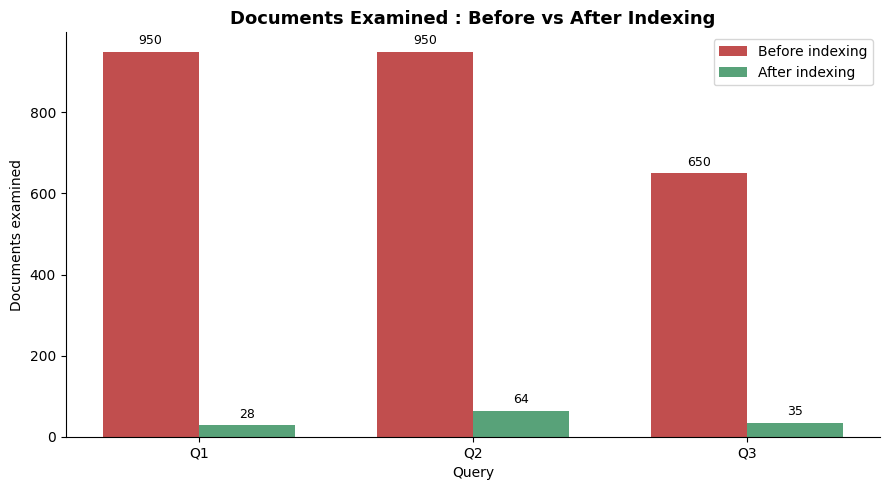

In [7]:
# 8.8 : Side-by-side comparison + visualisation

import pandas as pd
import matplotlib.pyplot as plt

rows = []
for b, i in zip(baseline, indexed):
    docs_examined_reduction = (
        (b['docs_examined'] - i['docs_examined']) / b['docs_examined'] * 100
        if b['docs_examined'] > 0 else 0
    )
    rows.append({
        'Query': b['label'],
        'Returned':            b['docs_returned'],
        'Examined (before)':   b['docs_examined'],
        'Examined (after)':    i['docs_examined'],
        'Examined Δ%':         f"{docs_examined_reduction:.1f}%",
        'Time before (ms)':    b['execution_time_ms'],
        'Time after (ms)':     i['execution_time_ms'],
        'Index used (after)':  i['index_used'],
    })

comparison_df = pd.DataFrame(rows)
print("Query optimisation comparison:")
print(comparison_df.to_string(index=False))

# --- Bar chart of docs_examined before vs after ---
fig, ax = plt.subplots(figsize=(9, 5))
labels   = [b['label'] for b in baseline]
before   = [b['docs_examined'] for b in baseline]
after    = [i['docs_examined'] for i in indexed]
x = range(len(labels))
width = 0.35

ax.bar([p - width/2 for p in x], before, width,
       label='Before indexing', color='#B22222', alpha=0.8)
ax.bar([p + width/2 for p in x], after,  width,
       label='After indexing',  color='#2E8B57', alpha=0.8)

# Annotate bar values
for i_, (b_val, a_val) in enumerate(zip(before, after)):
    ax.text(i_ - width/2, b_val + max(before)*0.02, f'{b_val}', ha='center', fontsize=9)
    ax.text(i_ + width/2, a_val + max(before)*0.02, f'{a_val}', ha='center', fontsize=9)

ax.set_xlabel('Query')
ax.set_ylabel('Documents examined')
ax.set_title('Documents Examined : Before vs After Indexing',
             fontweight='bold', fontsize=13)
ax.set_xticks(list(x))
ax.set_xticklabels(labels)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('plot_optimisation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Section Summary

Three indexes were created targeting three representative management queries. The `explain('executionStats')` output before and after indexing shows the reduction in documents examined and execution time. The bar chart visualises the effect quantitatively.

Notebook: `notebooks/05_query_optimisation.ipynb`.